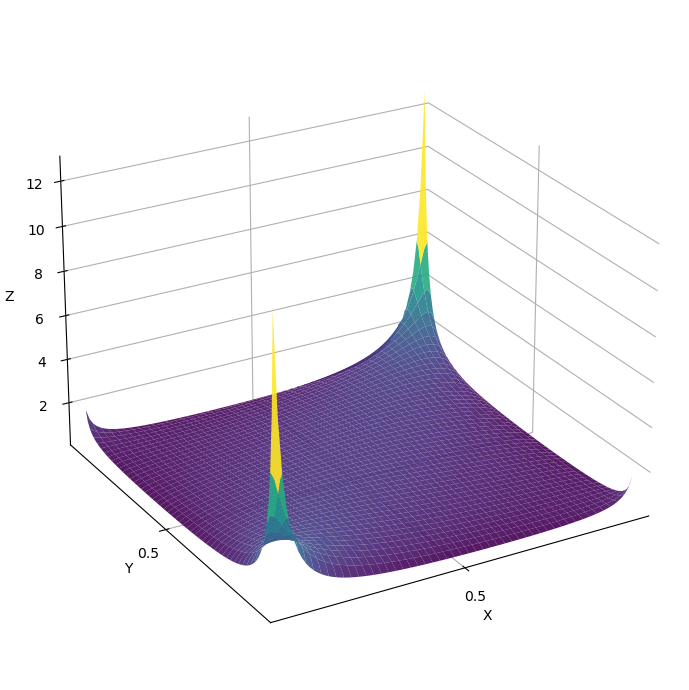

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist
from scipy.special import gamma

# ── 1. Parameters ─────────────────────────────────────────────────
r   = 0.4
v   = 3           # degrees of freedom
det_R = 1 - r**2

# ── 2. Grid on [0,1]^2 ────────────────────────────────────────────
u = np.arange(0.01, 1.00, 0.01)
w = np.arange(0.01, 1.00, 0.01)
U, W = np.meshgrid(u, w)

# ── 3. t quantile transform ───────────────────────────────────────
y1 = t_dist.ppf(U, v)   # qt(U, v)
y2 = t_dist.ppf(W, v)   # qt(W, v)

# ── 4. t-Student copula density ───────────────────────────────────
# c(u,w) = f(y1,y2; R,v) / (f_v(y1) * f_v(y2))
#
# Bivariate t density numerator terms:
#   (1 + y'R^{-1}y / v)^{-(v/2 + 1)}
# Univariate t density denominator terms:
#   (1 + y1^2/v)^{-(v+1)/2} * (1 + y2^2/v)^{-(v+1)/2}

# Normalizing constant g = sqrt(det_R) * Gamma(v/2) * Gamma(v/2+1) / Gamma((v+1)/2)^2
g = (1 / np.sqrt(det_R)) * gamma(v/2 + 1) * gamma(v/2) / gamma((v + 1) / 2)**2

# Quadratic form: y' R^{-1} y / v
Q = (y1**2 - 2*r*y1*y2 + y2**2) / (det_R * v)

# Density ratio
numer = (1 + y1**2 / v) * (1 + y2**2 / v)
denom = (1 + Q)

f = g * (numer ** ((v + 1) / 2)) / (denom ** (v / 2 + 1))

# ── 5. 3D surface plot ────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=600)

plt.tight_layout()
plt.savefig("t_copula_density.png", dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist
from scipy.special import gamma

OUTPUT_DIR = os.getcwd()

RHO = 0.4
DOF = 3
GRID_STEP = 0.01

**Cell 2 — Grid on (0,1)^2**

In [2]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)
w = np.arange(GRID_STEP, 1.00, GRID_STEP)
U, W = np.meshgrid(u, w)

**Cell 3 — t-copula density function**

In [3]:
def t_copula_density(U, W, rho, dof):
    det_R = 1 - rho**2
    y1 = t_dist.ppf(U, dof)
    y2 = t_dist.ppf(W, dof)

    g = (1 / np.sqrt(det_R)) * gamma(dof/2 + 1) * gamma(dof/2) / gamma((dof + 1) / 2)**2
    Q = (y1**2 - 2 * rho * y1 * y2 + y2**2) / (det_R * dof)
    numer = (1 + y1**2 / dof) * (1 + y2**2 / dof)
    denom = 1 + Q

    return g * (numer ** ((dof + 1) / 2)) / (denom ** (dof / 2 + 1))

f = t_copula_density(U, W, RHO, DOF)

**Cell 4 — 3D surface plot**

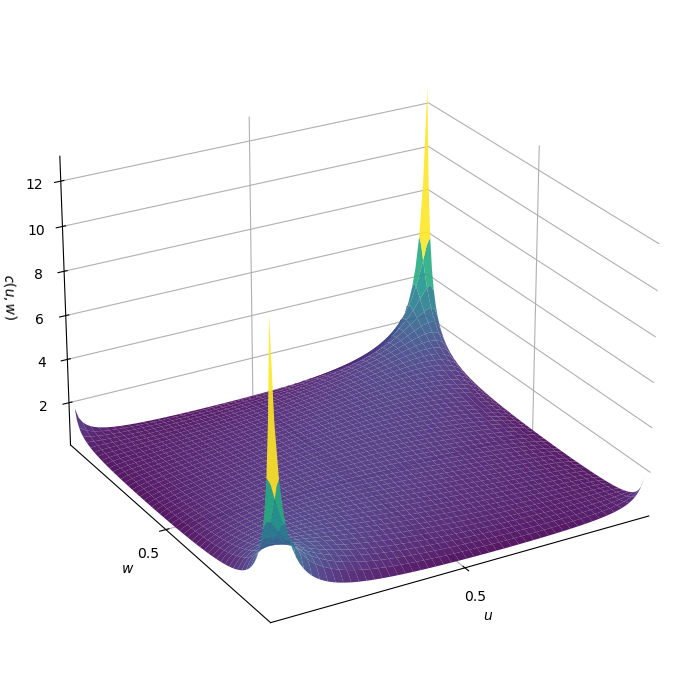

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$w$")
ax.set_zlabel("$c(u,w)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "t_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()